### **1. Importing Libraries**

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### **2. Loading the Data**

In [8]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset_path = './tiny-imagenet/train'
train_dataset = datasets.ImageFolder(root=train_dataset_path, transform=transform)
train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
print(f"Loaded {len(train_dataset)} training images.")

val_dataset_path = './tiny-imagenet/val'
val_dataset = datasets.ImageFolder(root=val_dataset_path, transform=transform)
val_dataloader = DataLoader(val_dataset, batch_size=64, shuffle=False)
print(f"Loaded {len(val_dataset)} validation images.")

Loaded 3500 training images.
Loaded 500 validation images.


### **3. Defining Nosie Functions**

In [9]:
def gauss_noise(images, mean=0.0, std=0.2):
    noise = torch.randn(images.size(), device=images.device) * std + mean
    noisy_images = images + noise
    return torch.clamp(noisy_images, 0., 1.)

def salt_pepp_noise(images, amount=0.05):
    noisy_images = images.clone()
    p = amount / 2.0
    
    salt_mask = torch.rand(images.size(), device=images.device) < p
    noisy_images[salt_mask] = 1.0
    
    pepper_mask = torch.rand(images.size(), device=images.device) < p
    noisy_images[pepper_mask] = 0.0
    
    return noisy_images

### **4. Creating the AutoEncoder**

In [10]:
class DAE(nn.Module):
    def __init__(self):
        super(DAE, self).__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1), 
            nn.BatchNorm2d(32),
            nn.ReLU(),
            
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), 
            nn.BatchNorm2d(64),
            nn.ReLU(),
            
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1), 
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        
        self.decoder = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(32, 3, kernel_size=3, padding=1),
            nn.Sigmoid() 
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

model = DAE().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

### **5. Training and Loss**

Epoch [1/30], Train MSE: 0.0212, Val MSE: 0.0161
Epoch [2/30], Train MSE: 0.0140, Val MSE: 0.0126
Epoch [3/30], Train MSE: 0.0129, Val MSE: 0.0118
Epoch [4/30], Train MSE: 0.0120, Val MSE: 0.0111
Epoch [5/30], Train MSE: 0.0115, Val MSE: 0.0105
Epoch [6/30], Train MSE: 0.0109, Val MSE: 0.0100
Epoch [7/30], Train MSE: 0.0109, Val MSE: 0.0101
Epoch [8/30], Train MSE: 0.0106, Val MSE: 0.0097
Epoch [9/30], Train MSE: 0.0104, Val MSE: 0.0095
Epoch [10/30], Train MSE: 0.0103, Val MSE: 0.0098
Epoch [11/30], Train MSE: 0.0102, Val MSE: 0.0093
Epoch [12/30], Train MSE: 0.0101, Val MSE: 0.0099
Epoch [13/30], Train MSE: 0.0099, Val MSE: 0.0092
Epoch [14/30], Train MSE: 0.0098, Val MSE: 0.0093
Epoch [15/30], Train MSE: 0.0097, Val MSE: 0.0090
Epoch [16/30], Train MSE: 0.0097, Val MSE: 0.0093
Epoch [17/30], Train MSE: 0.0097, Val MSE: 0.0089
Epoch [18/30], Train MSE: 0.0095, Val MSE: 0.0087
Epoch [19/30], Train MSE: 0.0096, Val MSE: 0.0089
Epoch [20/30], Train MSE: 0.0095, Val MSE: 0.0086
Epoch [21

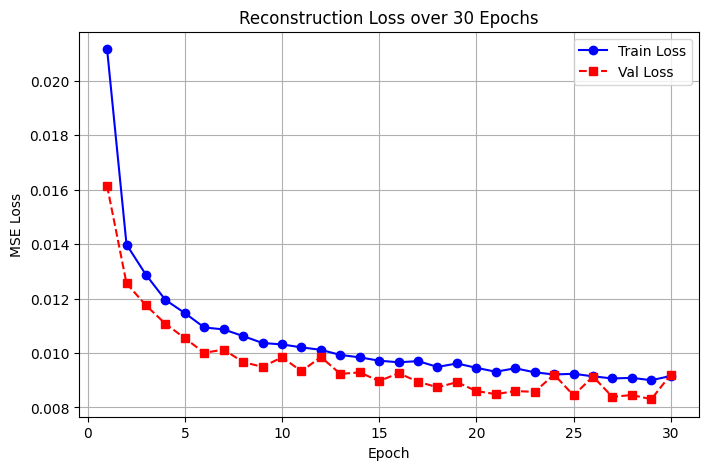

In [11]:
epochs = 30
noise_type = "gaussian"

train_losses = []
val_losses = []

for epoch in range(epochs):

    model.train()
    running_loss = 0.0
    for img, _ in train_dataloader:
        img = img.to(device)
        
        if noise_type == "gaussian":
            noisy_img = gauss_noise(img)
        else:
            noisy_img = salt_pepp_noise(img)
            
        optimizer.zero_grad()
        outputs = model(noisy_img)
        
        loss = criterion(outputs, img) 
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    avg_train_loss = running_loss / len(train_dataloader)
    train_losses.append(avg_train_loss)
    
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for val_img, _ in val_dataloader:
            val_img = val_img.to(device)
            
            if noise_type == "gaussian":
                noisy_val_img = gauss_noise(val_img)
            else:
                noisy_val_img = salt_pepp_noise(val_img)
                
            val_outputs = model(noisy_val_img)
            v_loss = criterion(val_outputs, val_img)
            val_loss += v_loss.item()
            
    avg_val_loss = val_loss / len(val_dataloader)
    val_losses.append(avg_val_loss) 
    
    print(f"Epoch [{epoch+1}/{epochs}], Train MSE: {avg_train_loss:.4f}, Val MSE: {avg_val_loss:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_losses, marker='o', linestyle='-', color='b', label='Train Loss')
plt.plot(range(1, epochs + 1), val_losses, marker='s', linestyle='--', color='r', label='Val Loss')
plt.title('Reconstruction Loss over 30 Epochs')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

### **6. Comparing Output with Original Images**

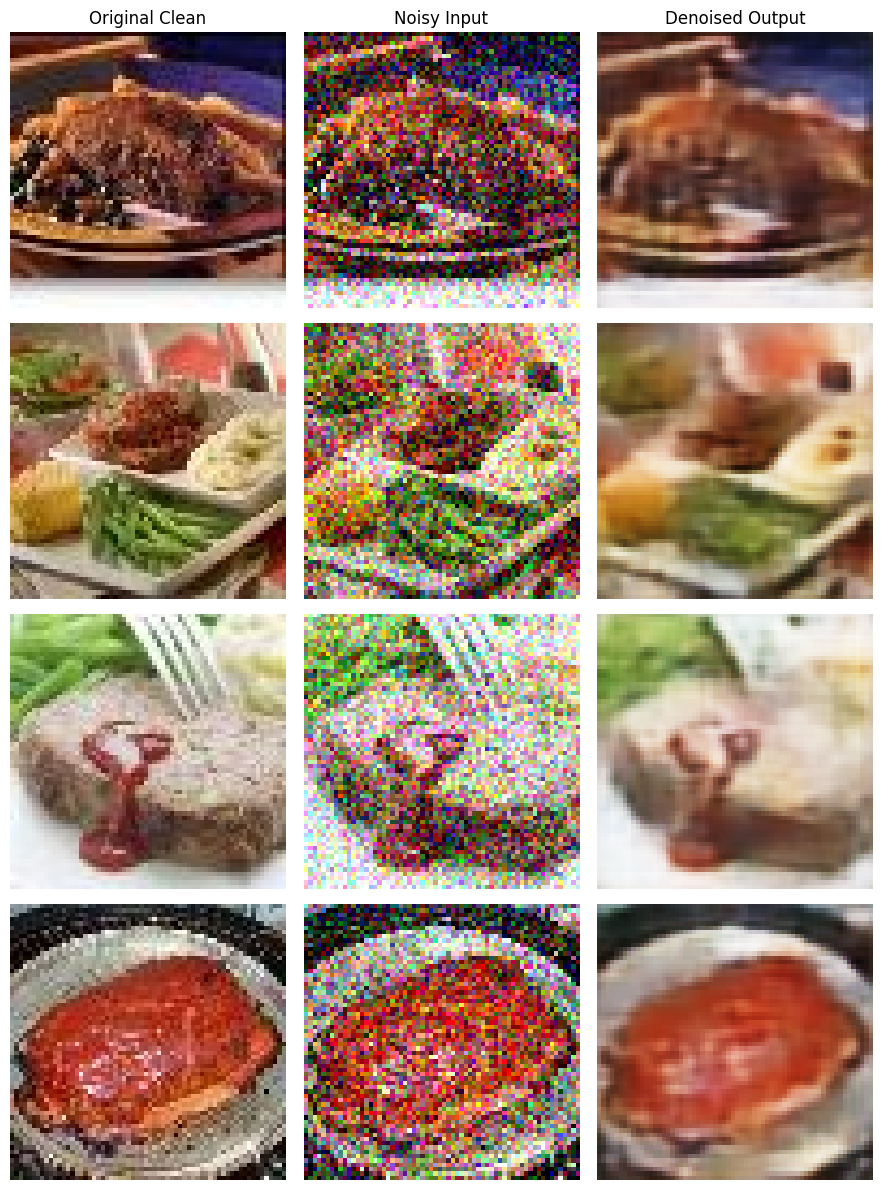

In [12]:
model.eval()

images, _ = next(iter(val_dataloader))
images = images.to(device)

if noise_type == "gaussian":
    noisy_images = gauss_noise(images)
else:
    noisy_images = salt_pepp_noise(images)

with torch.no_grad():
    denoised_images = model(noisy_images)

def imshow(img, title):
    npimg = img.cpu().numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(title)
    plt.axis('off')

plt.figure(figsize=(9, 12))
for i in range(4):
    plt.subplot(4, 3, i * 3 + 1)
    imshow(images[i], "Original Clean" if i == 0 else "")
    
    plt.subplot(4, 3, i * 3 + 2)
    imshow(noisy_images[i], "Noisy Input" if i == 0 else "")
    
    plt.subplot(4, 3, i * 3 + 3)
    imshow(denoised_images[i], "Denoised Output" if i == 0 else "")

plt.tight_layout()
plt.show()